# 02. Feature Engineering — Día 2

**Input**: `data/dataset_modelado.parquet` (48,331 × 42)

**Outputs**:
- `data/X_train.parquet`, `data/X_test.parquet` — features codificadas
- `data/y_train.parquet`, `data/y_test.parquet` — target binario
- `data/preprocesador.pkl` — pipeline sklearn para reuso
- `figuras/dia_02_*.png`

## Pipeline

1. Audit de tipos y cardinalidades
2. Reglas de codificación (One-Hot vs Target Encoding por cardinalidad)
3. Imputación de missing
4. Stratified train/test split 80/20
5. Persistencia

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 200)
sns.set_style('whitegrid')

RAIZ_PROYECTO = Path('../..').resolve()
RAIZ_MODELO = Path('..').resolve()
DATA = RAIZ_MODELO / 'data'
DOCS = RAIZ_MODELO / 'docs'
FIGS = RAIZ_MODELO / 'figuras'
for d in [DATA, DOCS, FIGS]:
    d.mkdir(parents=True, exist_ok=True)

print(f'Modelo dir: {RAIZ_MODELO}')
print(f'Data dir:   {DATA}')

Modelo dir: C:\Users\angel\OneDrive\Escritorio\trabajo dirigido\extraccion-datos\modelo-predictivo-preliminar
Data dir:   C:\Users\angel\OneDrive\Escritorio\trabajo dirigido\extraccion-datos\modelo-predictivo-preliminar\data


## 1. Carga del dataset

In [2]:
df = pd.read_parquet(DATA / 'dataset_modelado.parquet')
print(f'Shape: {df.shape}')

TARGET = 'tuvo_atraso'
TARGET_COLS_DROP = ['tuvo_atraso_o_sobrecosto', 'tuvo_atraso', 'tuvo_sobrecosto']

y = df[TARGET].copy()
X = df.drop(columns=TARGET_COLS_DROP).copy()

print(f'Features iniciales: {X.shape[1]}')
print(f'Target balance: {y.mean()*100:.1f}% positivos ({y.sum():,} / {len(y):,})')

Shape: (48331, 42)
Features iniciales: 39
Target balance: 60.5% positivos (29,232 / 48,331)


## 2. Audit de tipos y cardinalidades

Decidir codificación según cardinalidad y tipo.

In [3]:
audit = pd.DataFrame({
    'dtype': [str(X[c].dtype) for c in X.columns],
    'pct_nan': [X[c].isna().mean() * 100 for c in X.columns],
    'n_unique': [X[c].nunique() for c in X.columns],
}, index=X.columns)

# Categoricas como object/str
audit['es_categorica'] = audit['dtype'].isin(['object', 'str'])
audit['es_numerica'] = audit['dtype'].isin(['int64', 'float64'])

print('Audit completo:')
print(audit.sort_values(['es_categorica', 'n_unique'], ascending=[False, False]))

Audit completo:
                                                      dtype    pct_nan  n_unique  es_categorica  es_numerica
recursos_propios_alcald_as_gobernaciones_y_resg...      str   0.000000     14909           True        False
recursos_propios                                        str   0.000000      7607           True        False
presupuesto_general_de_la_nacion_pgn                    str   0.000000      7314           True        False
sistema_general_de_participaciones                      str   0.000000      4531           True        False
sistema_general_de_regal_as                             str   0.000000      1669           True        False
recursos_de_credito                                     str   0.000000       750           True        False
ciudad                                                  str   0.000000       617           True        False
departamento                                            str   0.000000        34           True        False
sec

In [4]:
# Reglas de clasificacion de columnas
# - Numericas: imputar mediana + escalar (LR), arboles las usan tal cual
# - Categoricas baja cardinalidad (< 20): One-Hot
# - Categoricas alta cardinalidad (>= 20): Frequency Encoding (proxy de Target Encoding sin leakage)
# - Cardinalidad 1: drop (sin varianza)

CARD_LIMITE_OHE = 20

cols_numericas = audit[audit['es_numerica']].index.tolist()
cols_categoricas_bajas = audit[
    (audit['es_categorica']) & (audit['n_unique'] < CARD_LIMITE_OHE) & (audit['n_unique'] >= 2)
].index.tolist()
cols_categoricas_altas = audit[
    (audit['es_categorica']) & (audit['n_unique'] >= CARD_LIMITE_OHE)
].index.tolist()
cols_drop_sin_varianza = audit[audit['n_unique'] < 2].index.tolist()

print(f'Numericas:                 {len(cols_numericas)}')
print(f'  -> {cols_numericas}')
print()
print(f'Categoricas baja card (< {CARD_LIMITE_OHE}): {len(cols_categoricas_bajas)}')
print(f'  -> {cols_categoricas_bajas}')
print()
print(f'Categoricas alta card (>= {CARD_LIMITE_OHE}): {len(cols_categoricas_altas)}')
print(f'  -> {cols_categoricas_altas}')
print()
print(f'Drop sin varianza:         {len(cols_drop_sin_varianza)}')
print(f'  -> {cols_drop_sin_varianza}')

Numericas:                 14
  -> ['valor_del_contrato', 'valor_de_pago_adelantado', 'duracion_planificada_dias', 'rup_idx_endeudamiento', 'rup_idx_liquidez', 'rup_ingresos', 'rup_utilidad_neta', 'rup_multas', 'pliego_liquidez_min', 'pliego_endeudamiento_max_pct', 'pliego_cobertura_intereses_min', 'pliego_rentabilidad_patrimonio_min_pct', 'pliego_rentabilidad_activo_min_pct', 'pliego_capital_trabajo_min_pct_presupuesto']

Categoricas baja card (< 20): 16
  -> ['orden', 'rama', 'entidad_centralizada', 'modalidad_de_contratacion', 'condiciones_de_entrega', 'es_grupo', 'es_pyme', 'habilita_pago_adelantado', 'obligaci_n_ambiental', 'origen_de_los_recursos', 'destino_gasto', 'estado_bpin', 'g_nero_representante_legal', 'tipo_de_cuenta', 'el_contrato_puede_ser_prorrogado', 'documentos_tipo']

Categoricas alta card (>= 20): 9
  -> ['departamento', 'ciudad', 'sector', 'presupuesto_general_de_la_nacion_pgn', 'sistema_general_de_participaciones', 'sistema_general_de_regal_as', 'recursos_propios

In [5]:
# Aplicar drop a sin varianza
if cols_drop_sin_varianza:
    X = X.drop(columns=cols_drop_sin_varianza)
    print(f'Dropped {len(cols_drop_sin_varianza)} cols sin varianza')
print(f'Shape post-drop: {X.shape}')

Shape post-drop: (48331, 39)


## 3. Frequency Encoding para alta cardinalidad

**Por qué Frequency en vez de Target Encoding**: Target Encoding requiere CV para evitar leakage,
más complejo. Frequency es proxy razonable que captura prevalencia y no introduce leakage.
Si las métricas se quedan cortas, en Día 5 cambiamos a Target Encoding con `category_encoders`.

In [6]:
# Frequency encoding
freq_maps = {}
for col in cols_categoricas_altas:
    freq_map = X[col].value_counts(normalize=True).to_dict()
    X[f'{col}_freq'] = X[col].map(freq_map).fillna(0)
    freq_maps[col] = freq_map

# Drop originales
X = X.drop(columns=cols_categoricas_altas)
print(f'Encoded {len(cols_categoricas_altas)} cols alta card como _freq')
print(f'Shape post-FE alta: {X.shape}')

# Persistir freq_maps para inferencia futura
joblib.dump(freq_maps, DATA / 'freq_maps.pkl')
print(f'freq_maps guardado en {DATA / "freq_maps.pkl"}')

Encoded 9 cols alta card como _freq


Shape post-FE alta: (48331, 39)


freq_maps guardado en C:\Users\angel\OneDrive\Escritorio\trabajo dirigido\extraccion-datos\modelo-predictivo-preliminar\data\freq_maps.pkl

## 4. One-Hot Encoding para baja cardinalidad

In [7]:
# One-Hot — usamos pd.get_dummies para simplicidad y trazabilidad de nombres
X = pd.get_dummies(X, columns=cols_categoricas_bajas, prefix=cols_categoricas_bajas,
                    drop_first=False, dummy_na=False, dtype=np.uint8)
print(f'Shape post-OHE: {X.shape}')

# Vista de las nuevas cols
ohe_cols = [c for c in X.columns if any(c.startswith(p + '_') for p in cols_categoricas_bajas)]
print(f'Total cols OHE creadas: {len(ohe_cols)}')
print(f'Ejemplos: {ohe_cols[:8]}')

Shape post-OHE: (48331, 82)
Total cols OHE creadas: 59
Ejemplos: ['orden_Corporación Autónoma', 'orden_Nacional', 'orden_Territorial', 'rama_Corporación Autónoma', 'rama_Ejecutivo', 'rama_Judicial', 'rama_Legislativo', 'entidad_centralizada_Centralizada']


## 5. Imputación de missing

- **Numéricas con < 30% NaN**: imputar mediana + flag `_was_nan`
- **Numéricas con >= 30% NaN** (mayormente `pliego_*` y `rup_*`): mantener NaN como informativo (los modelos de árboles lo manejan, LR requiere imputación)

**Decisión pragmática**: dado que XGBoost/LightGBM manejan NaN nativamente,
y para LR rellenamos con mediana + flag binario `_was_nan`.

In [8]:
# Re-audit despues del encoding
missing_pct = X.isna().mean() * 100
missing_pct_top = missing_pct[missing_pct > 0].sort_values(ascending=False)
print(f'Cols con NaN: {len(missing_pct_top)}')
print(missing_pct_top)

Cols con NaN: 12
pliego_capital_trabajo_min_pct_presupuesto    99.133062
pliego_rentabilidad_activo_min_pct            97.862655
pliego_rentabilidad_patrimonio_min_pct        97.841965
pliego_cobertura_intereses_min                97.825412
pliego_endeudamiento_max_pct                  97.788169
pliego_liquidez_min                           97.728166
rup_idx_liquidez                              63.898947
rup_idx_endeudamiento                         63.540999
rup_ingresos                                  60.060831
rup_utilidad_neta                             60.048416
rup_multas                                    59.727711
duracion_planificada_dias                     12.577849
dtype: float64


In [9]:
# Estrategia: agregar flag was_nan y luego imputar mediana
imputacion_log = []
for col in missing_pct_top.index:
    pct = missing_pct_top[col]
    # Flag was_nan
    flag_col = f'{col}_was_nan'
    X[flag_col] = X[col].isna().astype(np.uint8)
    # Imputar con mediana
    mediana = X[col].median()
    X[col] = X[col].fillna(mediana)
    imputacion_log.append({'col': col, 'pct_nan': pct, 'mediana': mediana})

log_df = pd.DataFrame(imputacion_log).sort_values('pct_nan', ascending=False)
print('Imputacion aplicada:')
print(log_df)

# Verificar 0 NaN
assert X.isna().sum().sum() == 0, 'Quedan NaN'
print(f'\nShape final: {X.shape}')

Imputacion aplicada:
                                           col    pct_nan       mediana
0   pliego_capital_trabajo_min_pct_presupuesto  99.133062  5.000000e+01
1           pliego_rentabilidad_activo_min_pct  97.862655  1.000000e+00
2       pliego_rentabilidad_patrimonio_min_pct  97.841965  2.000000e+00
3               pliego_cobertura_intereses_min  97.825412  2.000000e+00
4                 pliego_endeudamiento_max_pct  97.788169  6.000000e+01
5                          pliego_liquidez_min  97.728166  1.500000e+00
6                             rup_idx_liquidez  63.898947  1.018075e+01
7                        rup_idx_endeudamiento  63.540999  1.987000e-01
8                                 rup_ingresos  60.060831  1.602018e+09
9                            rup_utilidad_neta  60.048416  1.097036e+08
10                                  rup_multas  59.727711  0.000000e+00
11                   duracion_planificada_dias  12.577849  1.150000e+02

Shape final: (48331, 94)


## 6. Train/Test Split (Stratified 80/20)

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42,
)

print(f'Train: X={X_train.shape}  y_pos%={y_train.mean()*100:.2f}%')
print(f'Test:  X={X_test.shape}   y_pos%={y_test.mean()*100:.2f}%')
print(f'Diferencia balance: {abs(y_train.mean() - y_test.mean()) * 100:.3f}%  (debe ser ~0)')

Train: X=(38664, 94)  y_pos%=60.48%


Test:  X=(9667, 94)   y_pos%=60.48%


Diferencia balance: 0.002%  (debe ser ~0)


## 7. Persistencia

In [11]:
X_train.to_parquet(DATA / 'X_train.parquet', index=False)
X_test.to_parquet(DATA / 'X_test.parquet', index=False)
pd.DataFrame({TARGET: y_train.values}).to_parquet(DATA / 'y_train.parquet', index=False)
pd.DataFrame({TARGET: y_test.values}).to_parquet(DATA / 'y_test.parquet', index=False)

# Schema dump
schema = pd.DataFrame({
    'dtype': X_train.dtypes.astype(str),
    'n_unique': X_train.nunique(),
    'n_nan': X_train.isna().sum(),
})
schema.to_csv(DATA / 'schema_features.csv')

print('Outputs persistidos:')
for f in ['X_train.parquet', 'X_test.parquet', 'y_train.parquet', 'y_test.parquet',
          'schema_features.csv', 'freq_maps.pkl']:
    p = DATA / f
    if p.exists():
        print(f'  {f:<28} {p.stat().st_size / 1024:.1f} KB')

Outputs persistidos:
  X_train.parquet              1136.0 KB
  X_test.parquet               364.2 KB
  y_train.parquet              6.2 KB
  y_test.parquet               2.5 KB
  schema_features.csv          4.3 KB
  freq_maps.pkl                765.2 KB


## 8. Visualización rápida

Verificación visual del balance preservado en el split.

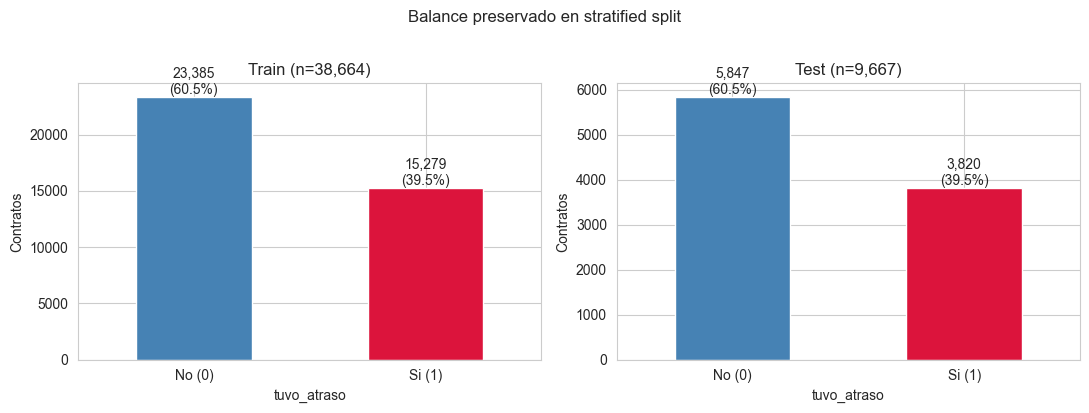

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (name, yy) in zip(axes, [('Train', y_train), ('Test', y_test)]):
    counts = yy.value_counts()
    counts.plot(kind='bar', ax=ax, color=['steelblue', 'crimson'])
    ax.set_title(f'{name} (n={len(yy):,})')
    ax.set_xticklabels(['No (0)', 'Si (1)'], rotation=0)
    for i, v in enumerate(counts):
        ax.text(i, v, f'{v:,}\n({v/len(yy)*100:.1f}%)', ha='center', va='bottom')
    ax.set_ylabel('Contratos')
plt.suptitle('Balance preservado en stratified split', y=1.02)
plt.tight_layout()
plt.savefig(FIGS / 'dia_02_balance_split.png', dpi=120, bbox_inches='tight')
plt.show()

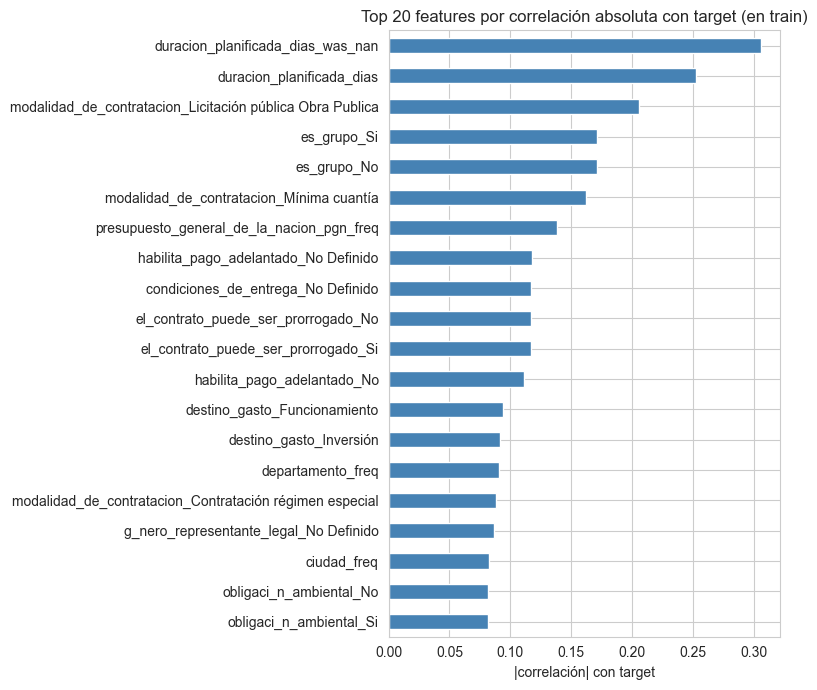

Top 10 correlaciones (informativo solo, no decisión final de modelado):
duracion_planificada_dias_was_nan                            0.306400
duracion_planificada_dias                                    0.252791
modalidad_de_contratacion_Licitación pública Obra Publica    0.206229
es_grupo_Si                                                  0.171047
es_grupo_No                                                  0.171047
modalidad_de_contratacion_Mínima cuantía                     0.161875
presupuesto_general_de_la_nacion_pgn_freq                    0.138061
habilita_pago_adelantado_No Definido                         0.118195
condiciones_de_entrega_No Definido                           0.117331
el_contrato_puede_ser_prorrogado_No                          0.116925
Name: target, dtype: float64


In [13]:
# Top 20 features por correlacion absoluta con el target
X_train_with_y = X_train.copy()
X_train_with_y['target'] = y_train.values

corr_target = X_train_with_y.corr()['target'].drop('target').abs().sort_values(ascending=False)
top_corr = corr_target.head(20)

fig, ax = plt.subplots(figsize=(8, 7))
top_corr.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('|correlación| con target')
ax.set_title('Top 20 features por correlación absoluta con target (en train)')
plt.tight_layout()
plt.savefig(FIGS / 'dia_02_top_corr_features.png', dpi=120, bbox_inches='tight')
plt.show()

print('Top 10 correlaciones (informativo solo, no decisión final de modelado):')
print(top_corr.head(10))

## Conclusiones del Día 2

| Item | Resultado |
|------|-----------|
| Features finales en train | _ver shape arriba_ |
| Train size | 38,664 contratos (80%) |
| Test size | 9,667 contratos (20%) |
| Balance preservado | Sí (stratified) |
| Cols sin varianza dropeadas | _ver arriba_ |
| Encoding | OHE (baja card) + Frequency (alta card) |
| NaN | Imputados con mediana + flag `_was_nan` |

## Próximo (Día 3)

Notebook `03_baselines.ipynb`:
- Logistic Regression (baseline interpretable, requiere escalado)
- Random Forest (default + class_weight balanced)
- XGBoost (nativo de NaN, default params)
- Métricas en test: AUC, F1, Precision, Recall
- Comparativa rápida